In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/train.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df[['Sales']].describe()


Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Basic statistics:


,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


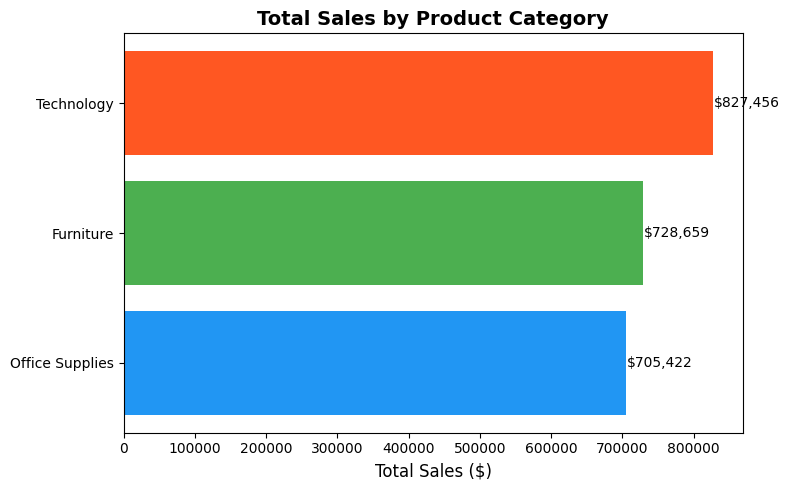

In [6]:
plt.figure(figsize=(8, 5))
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
colors = ['#2196F3', '#4CAF50', '#FF5722']
bars = plt.barh(cat_sales.index, cat_sales.values, color=colors)
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
for bar, val in zip(bars, cat_sales.values):
    plt.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart1_category.png', dpi=150)
plt.show()


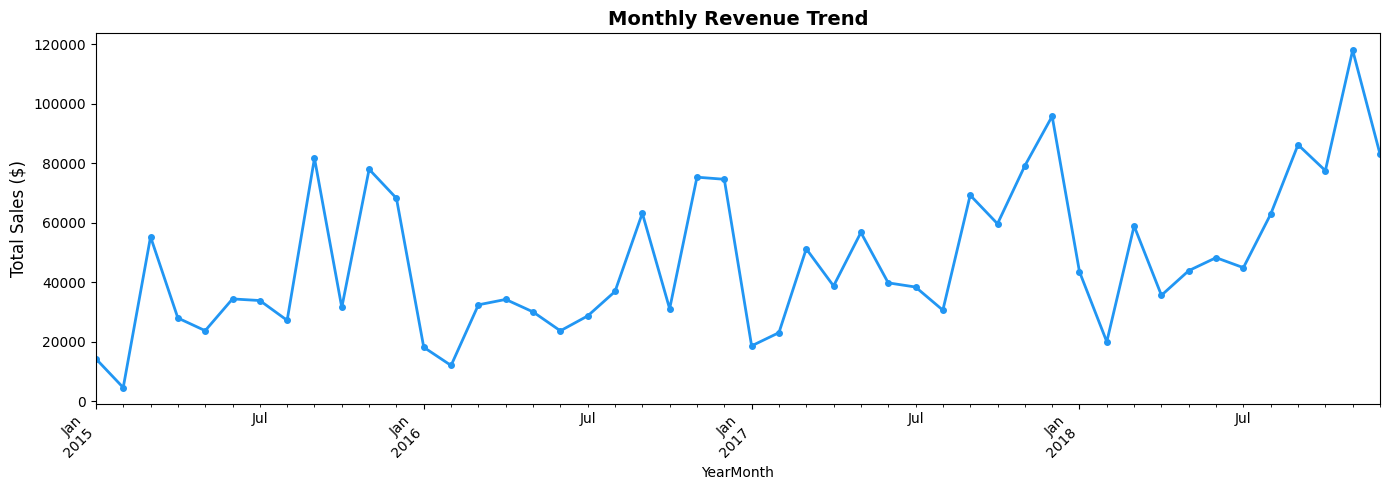

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly.plot(kind='line', marker='o', color='#2196F3', linewidth=2, markersize=4)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart2_monthly.png', dpi=150)
plt.show()

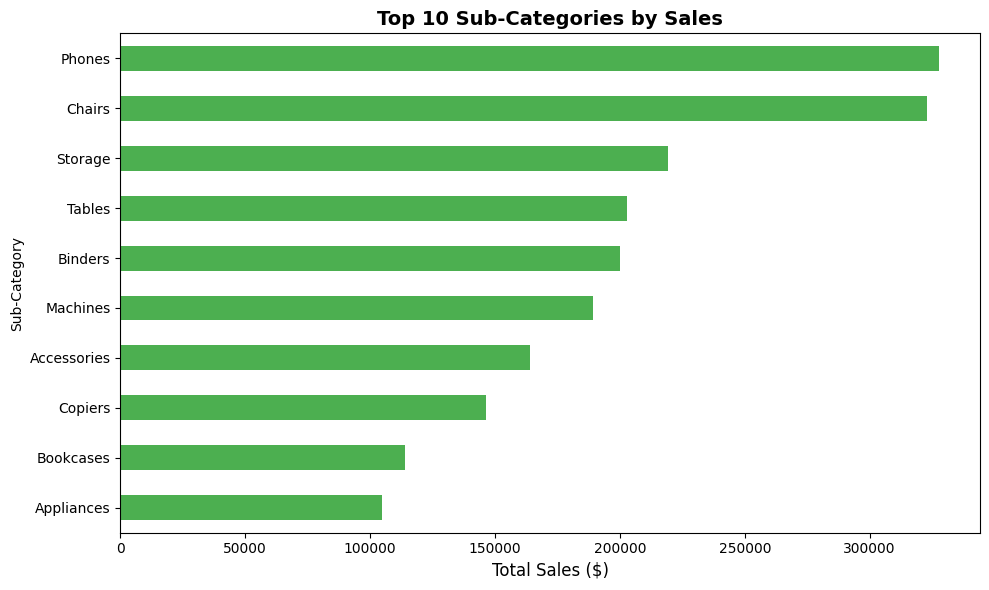

In [9]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().nlargest(10)
plt.figure(figsize=(10, 6))
top_sub.sort_values().plot(kind='barh', color='#4CAF50')
plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_subcategory.png', dpi=150)
plt.show()

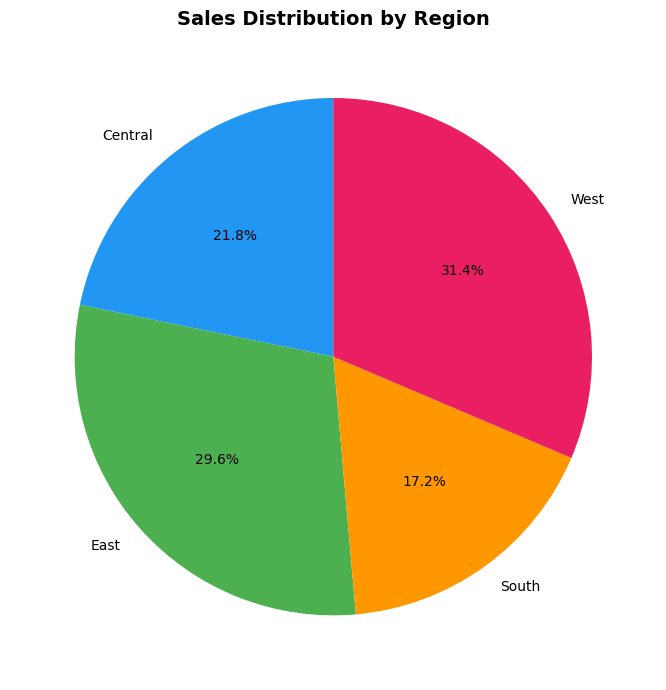

In [10]:
region_sales = df.groupby('Region')['Sales'].sum()
plt.figure(figsize=(7, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
plt.pie(region_sales.values, labels=region_sales.index,
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_region.png', dpi=150)
plt.show()

## Key Findings

**Dataset:** 9,800 retail orders from a US Superstore

1. **Technology leads in revenue** — highest total sales across all 3 categories. Office Supplies has the highest order volume but lowest average order value.

2. **Strong Q4 seasonality** — Sales spike every October–December. Q1 is consistently the weakest quarter across all years.

3. **West region dominates** — highest sales share among all 4 regions.

4. **Phones and Chairs are top sub-categories** — consistently the highest revenue drivers within their categories.

5. **Tables is the weakest sub-category** — lowest sales volume despite being a high-ticket item, indicating poor demand or heavy competition.

## Tools Used
- Python, Pandas, Matplotlib, Seaborn
- Dataset: Superstore Sales (Kaggle)

In [13]:
from google.colab import files
files.download('chart1_category.png')
files.download('chart2_monthly.png')
files.download('chart3_subcategory.png')
files.download('chart4_region.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>